In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../data/uac_data.csv')

In [3]:
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [4]:
df.shape

(1170, 6)

In [5]:
df.columns

Index(['Date', 'Children apprehended and placed in CBP custody*',
       'Children in CBP custody', 'Children transferred out of CBP custody',
       'Children in HHS Care', 'Children discharged from HHS Care'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    str    
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    str    
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), str(2)
memory usage: 55.0 KB


In [12]:
df = df.dropna()

In [13]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 720 entries, 2023-01-12 to 2025-12-21
Data columns (total 5 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Children apprehended and placed in CBP custody*  720 non-null    float64
 1   Children in CBP custody                          720 non-null    float64
 2   Children transferred out of CBP custody          720 non-null    float64
 3   Children in HHS Care                             720 non-null    str    
 4   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), str(1)
memory usage: 33.8 KB


In [7]:
df.isnull().sum()

Date                                               450
Children apprehended and placed in CBP custody*    450
Children in CBP custody                            450
Children transferred out of CBP custody            450
Children in HHS Care                               450
Children discharged from HHS Care                  450
dtype: int64

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

In [14]:
df['Children in HHS Care'] = (
    df['Children in HHS Care']
    .str.replace(',', '')
    .astype(float)
)

In [9]:
df = df.sort_values('Date')

In [10]:
df.set_index('Date', inplace=True)

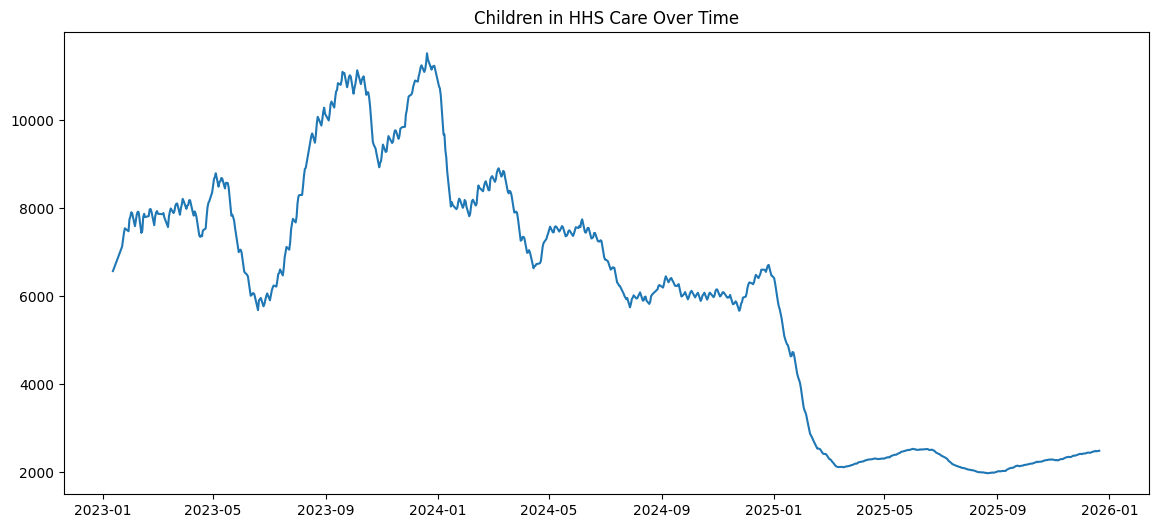

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(df['Children in HHS Care'])

plt.title('Children in HHS Care Over Time')

plt.show()

In [16]:
df.describe()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
count,720.000000,720.000000,720.000000,720.000000,720.000000
mean,93.523611,171.494444,128.668056,6061.275000,173.406944
std,72.646625,126.354965,97.322012,2833.070109,125.702841
min,0.000000,7.000000,0.000000,1972.000000,0.000000
25%,12.000000,36.000000,14.000000,2467.750000,19.750000
50%,99.000000,193.000000,157.000000,6406.500000,181.000000
75%,147.250000,263.250000,199.250000,8010.250000,267.000000
max,333.000000,531.000000,440.000000,11516.000000,505.000000


In [17]:
df.isnull().sum()

Children apprehended and placed in CBP custody*    0
Children in CBP custody                            0
Children transferred out of CBP custody            0
Children in HHS Care                               0
Children discharged from HHS Care                  0
dtype: int64

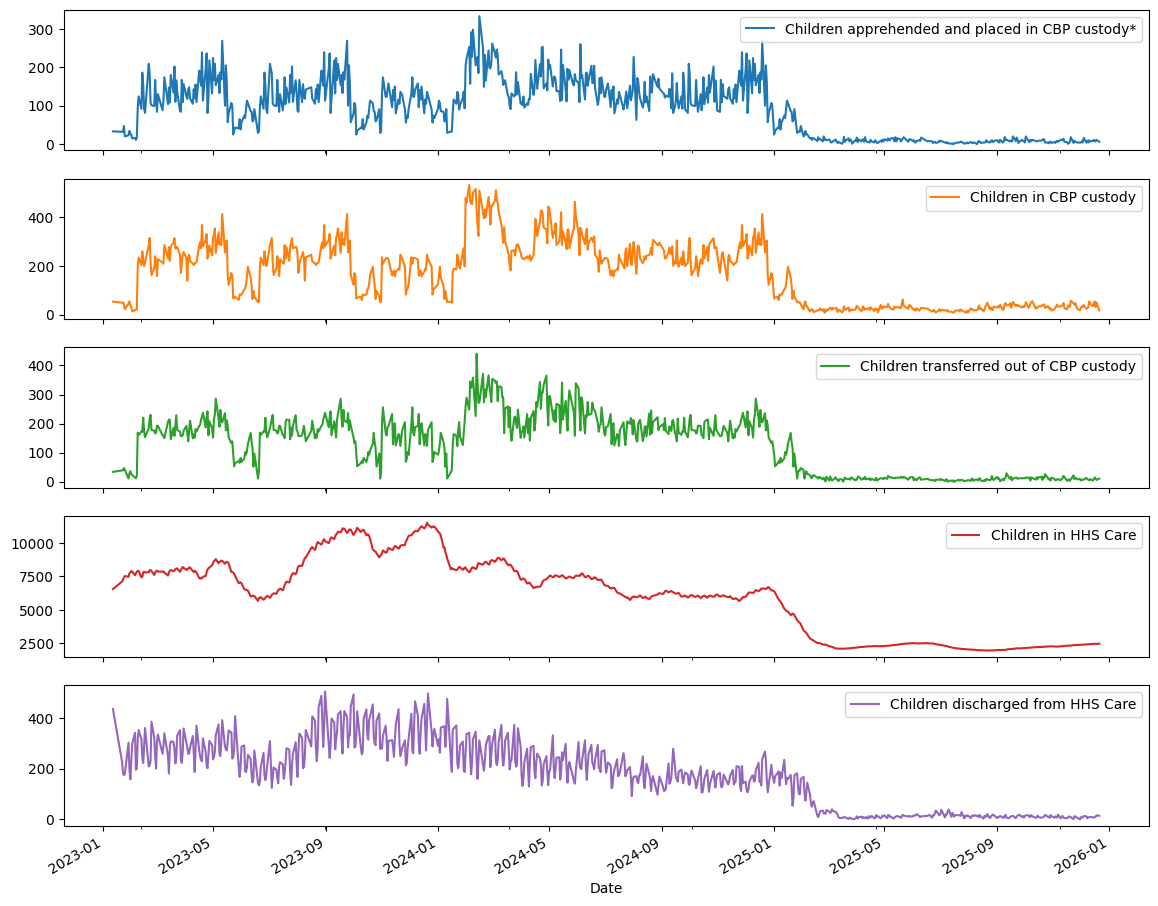

In [18]:
df.plot(subplots=True, figsize=(14,12))
plt.show()

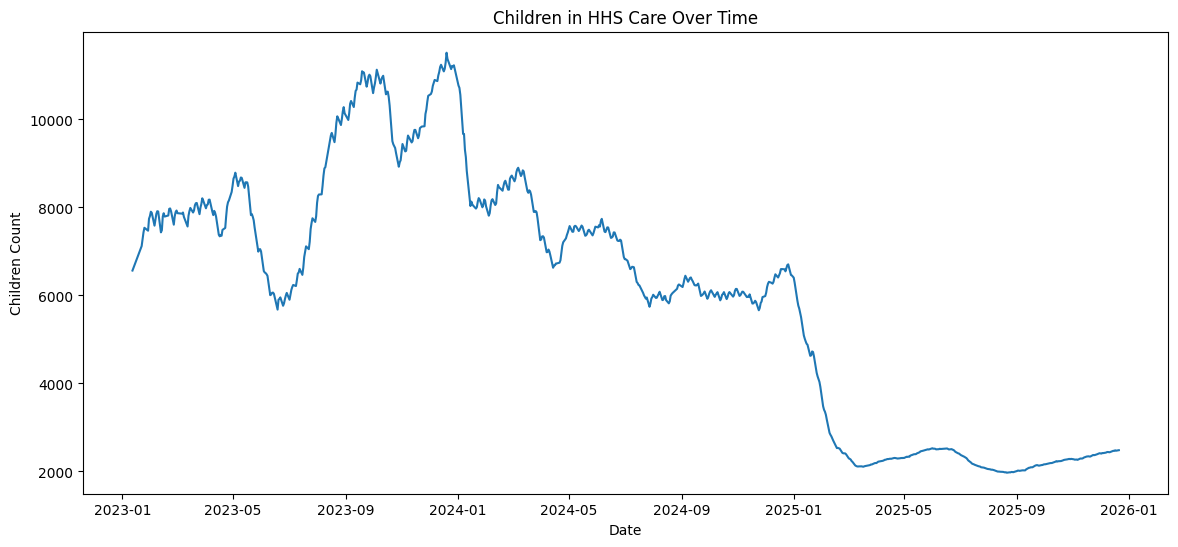

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(df['Children in HHS Care'])

plt.title('Children in HHS Care Over Time')

plt.xlabel('Date')

plt.ylabel('Children Count')

plt.show()

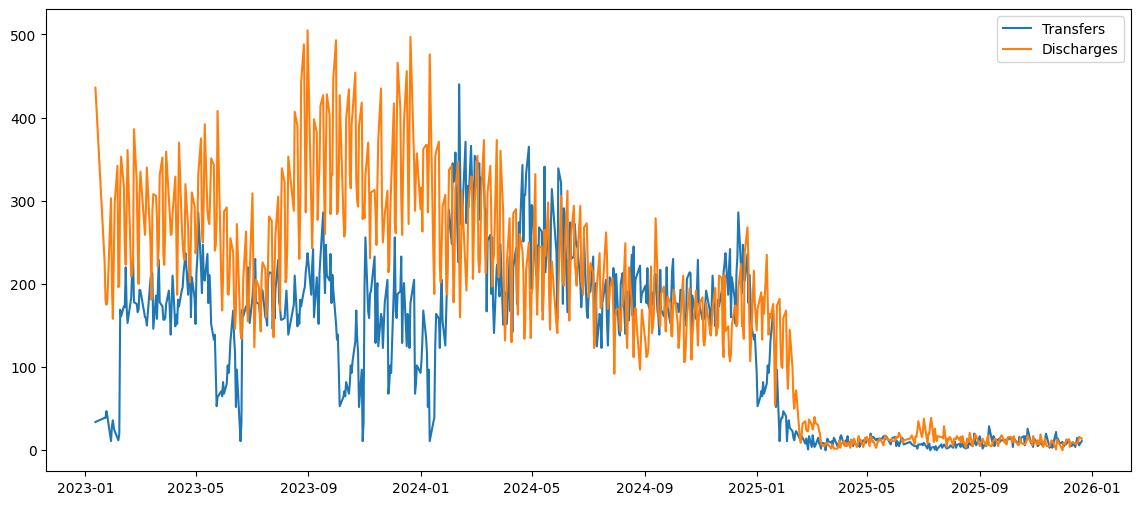

In [20]:
plt.figure(figsize=(14,6))

plt.plot(
    df['Children transferred out of CBP custody'],
    label='Transfers'
)

plt.plot(
    df['Children discharged from HHS Care'],
    label='Discharges'
)

plt.legend()

plt.show()